# Pregunta 3



## a) 

Cargamos los 3 dataframes y los ordenamos para que esten en el mismo formato.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pvlib as pvlib

# =============================================================================
# 1. CARGA DE LOS 3 ARCHIVOS CSV
# =============================================================================
# a) TMY Explorador Solar (Encabezado de metadatos: 41 lineas)
df_tmy_explorador = pd.read_csv('DatosSolaresTMY_ExploradorSolar.csv', skiprows=41)

# b) TMY PVGIS (Encabezado de metadatos: 17 lineas, 8760 horas correspondientes a 1 anio tipico)
df_tmy_pvgis = pd.read_csv('DatosSolaresTMY_PVGIS.csv', skiprows=17, nrows=8760)

# c) Serie Multianual Explorador Solar (Encabezado de metadatos: 41 lineas, 2004 a 2016 continuo)
df_multi_explorador = pd.read_csv('DatosSolares2004_2016_ExploradorSolar.csv', skiprows=41)

print(f"Filas leidas - TMY Explorador Solar:      {len(df_tmy_explorador):,}")
print(f"Filas leidas - TMY PVGIS:                 {len(df_tmy_pvgis):,}")
print(f"Filas leidas - Serie Multianual Explorador: {len(df_multi_explorador):,}")

Filas leidas - TMY Explorador Solar:      8,760
Filas leidas - TMY PVGIS:                 8,760
Filas leidas - Serie Multianual Explorador: 113,952


In [25]:
# =============================================================================
# 2. TRATAMIENTO DE LA VARIABLE TEMPORAL
# =============================================================================
# Conversion uniforme de la columna temporal a datetime64 en los 3 dataframes
df_tmy_explorador['fecha_hora'] = pd.to_datetime(df_tmy_explorador['Fecha/Hora'])
df_multi_explorador['fecha_hora'] = pd.to_datetime(df_multi_explorador['Fecha/Hora'])

# En PVGIS el formato viene como 'YYYYMMDD:HHMM' en UTC
df_tmy_pvgis['fecha_hora'] = pd.to_datetime(df_tmy_pvgis['time(UTC)'], format='%Y%m%d:%H%M')

# Opcional: Si se requiere convertir PVGIS a hora local de Chile (America/Santiago / UTC-4 / UTC-3):
df_tmy_pvgis['fecha_hora'] = df_tmy_pvgis['fecha_hora'].dt.tz_localize('UTC').dt.tz_convert('America/Santiago').dt.tz_localize(None)

# =============================================================================
# 3. HOMOLOGACION, FILTRADO Y ORDENAMIENTO DE VARIABLES
# =============================================================================
# Diccionario de renombramiento para Explorador Solar
rename_explorador = {
    'ghi': 'ghi',     # Radiacion Global Horizontal [W/m2]
    'dni': 'dni',     # Radiacion Directa Normal [W/m2]
    'difh': 'dhi',    # Radiacion Difusa Horizontal [W/m2]
    'temp': 'temp',   # Temperatura a 2 metros [deg C]
    'vel': 'vel'      # Velocidad de viento [m/s]
}

# Diccionario de renombramiento para PVGIS
rename_pvgis = {
    'G(h)': 'ghi',    # Radiacion Global Horizontal [W/m2]
    'Gb(n)': 'dni',   # Radiacion Directa Normal [W/m2]
    'Gd(h)': 'dhi',   # Radiacion Difusa Horizontal [W/m2]
    'T2m': 'temp',    # Temperatura a 2 metros [deg C]
    'WS10m': 'vel'    # Velocidad de viento a 10m [m/s]
}

# Aplicar renombramiento
df_tmy_explorador = df_tmy_explorador.rename(columns=rename_explorador)
df_multi_explorador = df_multi_explorador.rename(columns=rename_explorador)
df_tmy_pvgis = df_tmy_pvgis.rename(columns=rename_pvgis)

# Definicion estricta del orden y nombres de columnas comunes
columnas_comunes = ['fecha_hora', 'ghi', 'dni', 'dhi', 'temp', 'vel']

# Filtrar y ordenar los 3 DataFrames exactamente con las mismas columnas
df_tmy_explorador = df_tmy_explorador[columnas_comunes].copy()
df_tmy_pvgis = df_tmy_pvgis[columnas_comunes].copy()
df_multi_explorador = df_multi_explorador[columnas_comunes].copy()

# =============================================================================
# 4. VALIDACION DE CONSISTENCIA
# =============================================================================
print("Columnas en TMY Explorador Solar:", df_tmy_explorador.columns.tolist())
print("Columnas en TMY PVGIS:           ", df_tmy_pvgis.columns.tolist())
print("Columnas en Serie Multianual:    ", df_multi_explorador.columns.tolist())

assert list(df_tmy_explorador.columns) == list(df_tmy_pvgis.columns) == list(df_multi_explorador.columns) == columnas_comunes, "Las columnas no coinciden!"
print("\n[OK] Los 3 DataFrames tienen exactamente las mismas columnas y el mismo orden!")

Columnas en TMY Explorador Solar: ['fecha_hora', 'ghi', 'dni', 'dhi', 'temp', 'vel']
Columnas en TMY PVGIS:            ['fecha_hora', 'ghi', 'dni', 'dhi', 'temp', 'vel']
Columnas en Serie Multianual:     ['fecha_hora', 'ghi', 'dni', 'dhi', 'temp', 'vel']

[OK] Los 3 DataFrames tienen exactamente las mismas columnas y el mismo orden!


In [26]:
# Verificacion de las primeras 5 filas de cada DataFrame
print("=== Primeras 5 filas: df_tmy_explorador ===")
display(df_tmy_explorador.head())

print("=== Primeras 5 filas: df_tmy_pvgis ===")
display(df_tmy_pvgis.head())

print("=== Primeras 5 filas: df_multi_explorador ===")
display(df_multi_explorador.head())

=== Primeras 5 filas: df_tmy_explorador ===


,fecha_hora,ghi,dni,dhi,temp,vel
0,2006-01-01 00:00:00,0.0,0.0,0.0,15.48,2.60
1,2006-01-01 01:00:00,0.0,0.0,0.0,14.72,2.89
2,2006-01-01 02:00:00,0.0,0.0,0.0,14.26,2.76
3,2006-01-01 03:00:00,0.0,0.0,0.0,13.23,2.57
4,2006-01-01 04:00:00,0.0,0.0,0.0,11.98,2.74


=== Primeras 5 filas: df_tmy_pvgis ===


,fecha_hora,ghi,dni,dhi,temp,vel
0,2016-12-31 21:00:00,0.0,-0.0,0.0,14.03,0.91
1,2016-12-31 22:00:00,0.0,-0.0,0.0,13.59,0.85
2,2016-12-31 23:00:00,0.0,-0.0,0.0,13.15,0.79
3,2017-01-01 00:00:00,0.0,-0.0,0.0,12.72,0.73
4,2017-01-01 01:00:00,0.0,-0.0,0.0,12.28,0.67


=== Primeras 5 filas: df_multi_explorador ===


,fecha_hora,ghi,dni,dhi,temp,vel
0,2004-01-01 00:00:00,0.0,0.0,0.0,16.54,2.47
1,2004-01-01 01:00:00,0.0,0.0,0.0,15.74,2.51
2,2004-01-01 02:00:00,0.0,0.0,0.0,15.30,2.12
3,2004-01-01 03:00:00,0.0,0.0,0.0,14.43,2.20
4,2004-01-01 04:00:00,0.0,0.0,0.0,13.22,2.54


Se crea en base a los dataframes, la tabla con los totales de GHI y DNI por fuente. Se considera la desviacion de los datos de PVGIS, respecto al explorador.

In [27]:
#formato temporal
for df in [df_tmy_explorador, df_tmy_pvgis, df_multi_explorador]:
    df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])
    df['año'] = df['fecha_hora'].dt.year
    df['mes'] = df['fecha_hora'].dt.month
    df['hora'] = df['fecha_hora'].dt.hour

# sumar los totales
ghi_exp = df_tmy_explorador['ghi'].sum() / 1000.0
dni_exp = df_tmy_explorador['dni'].sum() / 1000.0

ghi_pvgis = df_tmy_pvgis['ghi'].sum() / 1000.0
dni_pvgis = df_tmy_pvgis['dni'].sum() / 1000.0

# desviaciones relativas
eps_ghi = ((ghi_pvgis - ghi_exp) / ghi_exp) * 100.0
eps_dni = ((dni_pvgis - dni_exp) / dni_exp) * 100.0

#nueva tabla con los totales
df_tabla_totales = pd.DataFrame({
    'Variable': ['GHI [kWh/m²·año]', 'DNI [kWh/m²·año]'],
    'Explorador Solar': [ghi_exp, dni_exp],
    'PVGIS': [ghi_pvgis, dni_pvgis],
    'Desviación[%]': [eps_ghi, eps_dni]})

df_tabla_totales.head()

,Variable,Explorador Solar,PVGIS,Desviación[%]
0,GHI [kWh/m²·año],2129.4943,2303.79592,8.185118
1,DNI [kWh/m²·año],2416.2451,2766.67764,14.503187


Ahora, se consideran los totales mensuales de las 2 variables

In [28]:
mensual_exp = (df_tmy_explorador.groupby('mes')[['ghi', 'dni']].sum() / 1000.0)
mensual_pvgis = (df_tmy_pvgis.groupby('mes')[['ghi', 'dni']].sum() / 1000.0)

print(mensual_exp)
print(mensual_pvgis)

           ghi        dni
mes                      
1    283.05198  346.16237
2    230.87454  283.57244
3    208.98062  260.13114
4    143.00052  181.37408
5     94.42386  104.85857
6     69.13014   63.94526
7     69.79654   51.59146
8    105.49444   97.21549
9    161.07756  174.77870
10   223.16384  247.99905
11   258.42346  296.31323
12   282.07680  308.30331
           ghi        dni
mes                      
1    271.17734  305.00860
2    206.80699  220.54711
3    216.37601  265.11741
4    164.45040  228.53283
5    129.25795  202.55832
6     97.52361  139.62626
7    121.84590  168.51512
8    160.75313  222.69600
9    169.12703  176.81318
10   234.06621  259.70703
11   262.18396  287.68354
12   270.22739  289.87224


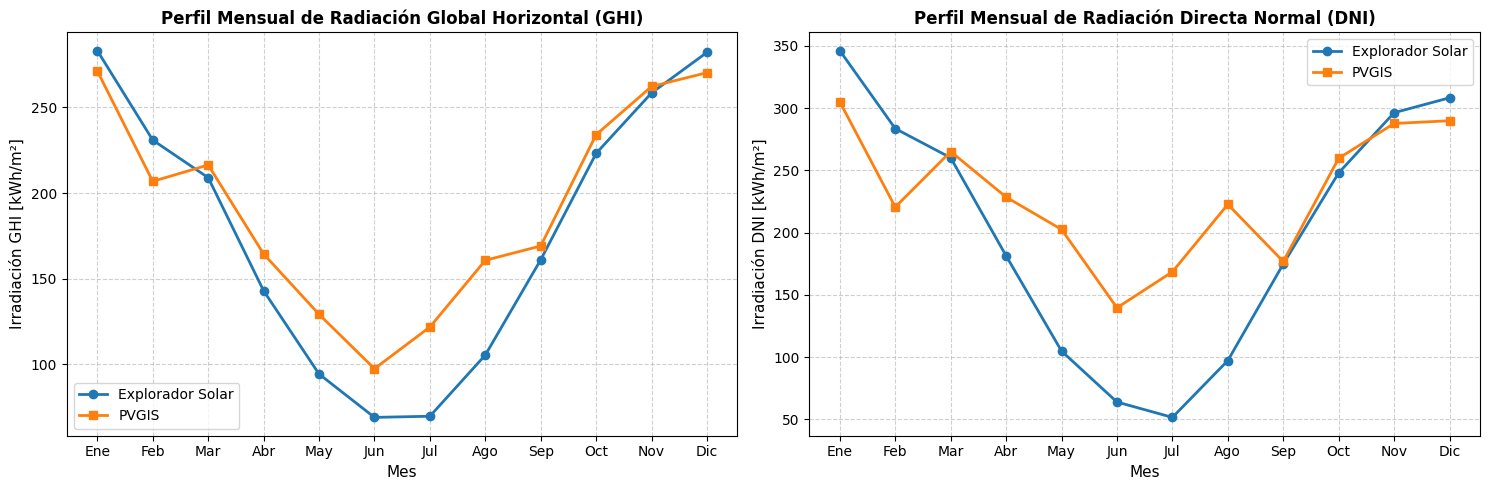

In [29]:
# =============================================================================
# PERFILES MENSUALES DE GHI Y DNI: EXPLORADOR SOLAR VS. PVGIS
# =============================================================================
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Crear figura con 2 graficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Grafico 1: Perfil Mensual de GHI ---
axes[0].plot(mensual_exp.index, mensual_exp['ghi'], marker='o', linewidth=2, color='#1f77b4', label='Explorador Solar')
axes[0].plot(mensual_pvgis.index, mensual_pvgis['ghi'], marker='s', linewidth=2, color='#ff7f0e', label='PVGIS')
axes[0].set_title('Perfil Mensual de Radiación Global Horizontal (GHI)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mes', fontsize=11)
axes[0].set_ylabel('Irradiación GHI [kWh/m²]', fontsize=11)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=10)

# --- Grafico 2: Perfil Mensual de DNI ---
axes[1].plot(mensual_exp.index, mensual_exp['dni'], marker='o', linewidth=2, color='#1f77b4', label='Explorador Solar')
axes[1].plot(mensual_pvgis.index, mensual_pvgis['dni'], marker='s', linewidth=2, color='#ff7f0e', label='PVGIS')
axes[1].set_title('Perfil Mensual de Radiación Directa Normal (DNI)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mes', fontsize=11)
axes[1].set_ylabel('Irradiación DNI [kWh/m²]', fontsize=11)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(meses)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

Luego, se grafica el mapa de calor, donde se compara la disponibilidad energetica por hora x mes, de la diferencia entre ambas fuentes

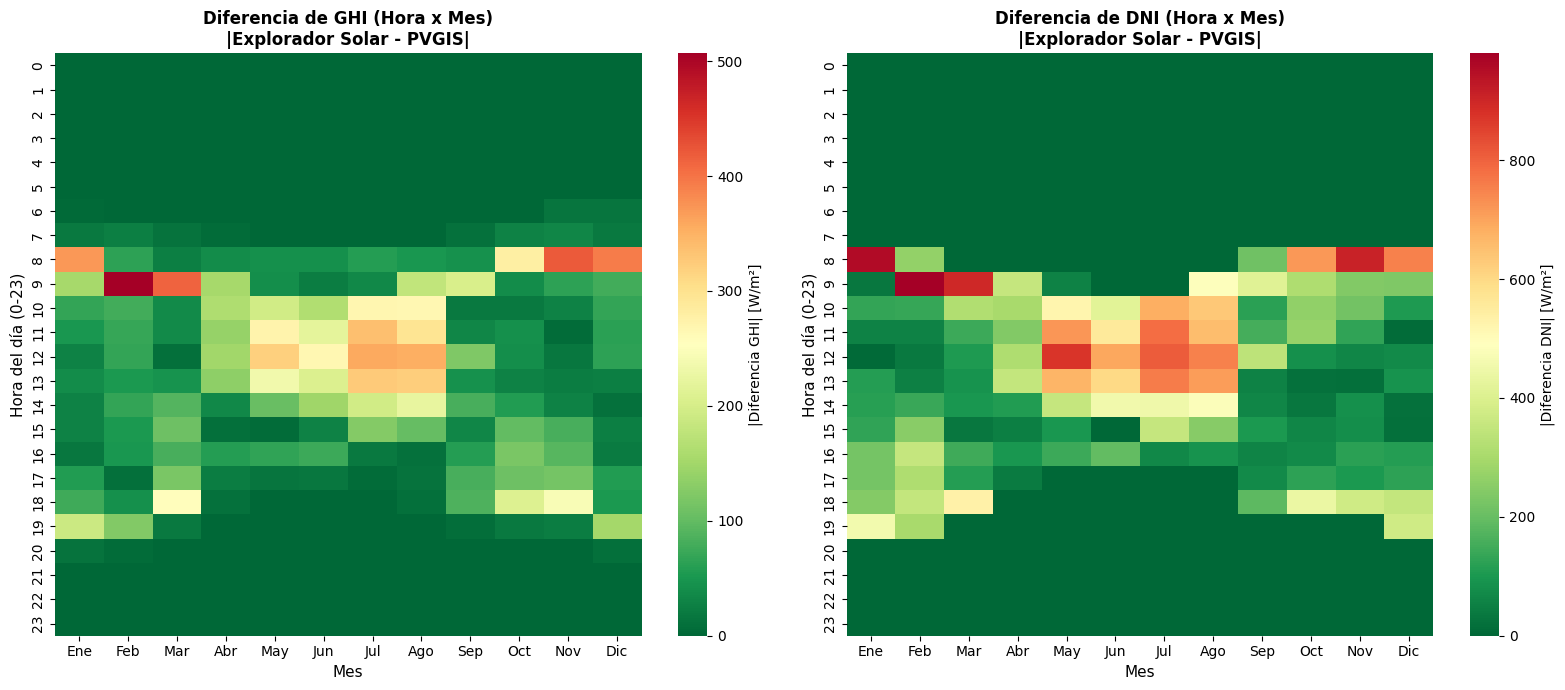

In [30]:
# =============================================================================
# 1. CREACION DE MALLAS 24 x 12 (PROMEDIO HORA x MES)
# =============================================================================
# Mallas para GHI (24 horas x 12 meses)
malla_ghi_exp = df_tmy_explorador.pivot_table(index='hora', columns='mes', values='ghi', aggfunc='mean')
malla_ghi_pvgis = df_tmy_pvgis.pivot_table(index='hora', columns='mes', values='ghi', aggfunc='mean')

# Mallas para DNI (24 horas x 12 meses)
malla_dni_exp = df_tmy_explorador.pivot_table(index='hora', columns='mes', values='dni', aggfunc='mean')
malla_dni_pvgis = df_tmy_pvgis.pivot_table(index='hora', columns='mes', values='dni', aggfunc='mean')

# =============================================================================
# 2. RESTA DE MALLAS (MAGNITUD DE LA DIFERENCIA)
# =============================================================================
# Se calcula el valor absoluto de la resta para que las mayores diferencias correspondan al rojo (extremo superior de la paleta)
diff_ghi = (malla_ghi_exp - malla_ghi_pvgis).abs()
diff_dni = (malla_dni_exp - malla_dni_pvgis).abs()

# =============================================================================
# 3. GRAFICO DE MAPAS DE CALOR CON SEABORN (PALETA VERDE A ROJO)
# =============================================================================
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Mapa de Calor: GHI ---
sns.heatmap(diff_ghi, ax=axes[0], cmap='RdYlGn_r', xticklabels=meses, yticklabels=True,
            cbar_kws={'label': '|Diferencia GHI| [W/m²]'})
axes[0].set_title('Diferencia de GHI (Hora x Mes)\n|Explorador Solar - PVGIS|', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mes', fontsize=11)
axes[0].set_ylabel('Hora del día (0-23)', fontsize=11)

# --- Mapa de Calor: DNI ---
sns.heatmap(diff_dni, ax=axes[1], cmap='RdYlGn_r', xticklabels=meses, yticklabels=True,
            cbar_kws={'label': '|Diferencia DNI| [W/m²]'})
axes[1].set_title('Diferencia de DNI (Hora x Mes)\n|Explorador Solar - PVGIS|', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mes', fontsize=11)
axes[1].set_ylabel('Hora del día (0-23)', fontsize=11)

plt.tight_layout()
plt.show()

## b)

Ahora interesa comparar, ocupando la base de datos de la serie multianual de REcurso SOlar, la variabilidad y diferencias que hay en la radiación reportada año a año. Para ello, se realiza una tabla con las medias de GHI de todos los años en la serie

In [31]:
df_multi_explorador.head()

,fecha_hora,ghi,dni,dhi,temp,vel,año,mes,hora
0,2004-01-01 00:00:00,0.0,0.0,0.0,16.54,2.47,2004,1,0
1,2004-01-01 01:00:00,0.0,0.0,0.0,15.74,2.51,2004,1,1
2,2004-01-01 02:00:00,0.0,0.0,0.0,15.30,2.12,2004,1,2
3,2004-01-01 03:00:00,0.0,0.0,0.0,14.43,2.20,2004,1,3
4,2004-01-01 04:00:00,0.0,0.0,0.0,13.22,2.54,2004,1,4


In [32]:
anual_multi = df_multi_explorador.groupby('año')[['ghi','dni']].sum()/1000

definiendo una funcion para calcular las metricas estadisticas

In [33]:
def calcular_metricas(serie, nombre_var):
    p50 = serie.mean()
    sigma = serie.std(ddof=1)
    cv = sigma / p50
    mejor_año_val = serie.max()
    mejor_año_num = serie.idxmax()
    peor_año_val = serie.min()
    peor_año_num = serie.idxmin()
    p90 = p50 - 1.28 * sigma
    
    return {
        'Variable': nombre_var,
        'P50 [kWh/m2 x año]': p50,
        'Desv. Estándar [kWh/m2 x año]': sigma,
        'CV  [%]': cv * 100,
        'Mejor Año': f"{mejor_año_val:.2f} ({mejor_año_num})",
        'Peor Año': f"{peor_año_val:.2f} ({peor_año_num})",
        'P90 [kWh/m2 x año]': p90
    }

In [34]:
estad_ghi = calcular_metricas(anual_multi['ghi'],'ghi')
estad_dni = calcular_metricas(anual_multi['dni'],'dni')

df_estad = pd.DataFrame([estad_ghi,estad_dni])
df_estad.head()

,Variable,P50 [kWh/m2 x año],Desv. Estándar [kWh/m2 x año],CV [%],Mejor Año,Peor Año,P90 [kWh/m2 x año]
0,ghi,2142.640323,104.18191,4.862314,2339.52 (2010),1986.33 (2016),2009.287478
1,dni,2498.908835,276.30517,11.057033,3008.33 (2010),2105.82 (2015),2145.238218


Luego se raliza una comparacion para ver que tan representativo es el TMY

In [35]:
anual_ghi_multi = anual_multi['ghi'] 
p50_multi = estad_ghi['P50 [kWh/m2 x año]'] #media de todos los años serie interanual

ghi_tmy_val = ghi_exp #total ghi TMY

# df con error de totales anuales vs total tmy
df_rep_tmy = pd.DataFrame({
    'Año': anual_ghi_multi.index,
    'GHI Anual [kWh/m2 x año]': anual_ghi_multi.values,
    'GHI TMY [kWh/m2 x año]': ghi_tmy_val,
    'Error Relativo vs TMY [%]': ((anual_ghi_multi.values - ghi_tmy_val) / ghi_tmy_val) * 100.0
})

#error promedio multianual vs total TMY
error_p50_vs_tmy = ((p50_multi - ghi_tmy_val) / ghi_tmy_val) * 100.0

fila_resumen = pd.DataFrame([{
    'Año': 'Promedio (P50)',
    'GHI Anual [kWh/m2 x año]': p50_multi,
    'GHI TMY [kWh/m2 x año]': ghi_tmy_val,
    'Error Relativo vs TMY [%]': error_p50_vs_tmy
}])

df_representatividad = pd.concat([df_rep_tmy, fila_resumen], ignore_index=True)

display(df_representatividad.round(2))

,Año,GHI Anual [kWh/m2 x año],GHI TMY [kWh/m2 x año],Error Relativo vs TMY [%]
0,2004,2156.54,2129.49,1.27
1,2005,2085.34,2129.49,-2.07
2,2006,2125.50,2129.49,-0.19
3,2007,2088.15,2129.49,-1.94
4,2008,2090.32,2129.49,-1.84
5,2009,2097.73,2129.49,-1.49
6,2010,2339.52,2129.49,9.86
7,2011,2280.16,2129.49,7.08
8,2012,2245.78,2129.49,5.46
9,2013,2178.75,2129.49,2.31


<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Diego Gutierrez\AppData\Local\Temp\ipykernel_11612\1086942548.py:16: SyntaxWarning: invalid escape sequence '\m'
  axs[0].plot(x_lin, stats.norm.pdf(x_lin, mu, sigma), 'r-', lw=2, label=f'Ajuste Normal ($\mu={mu:.1f}$, $\sigma={sigma:.1f}$)')
C:\Users\Diego Gutierrez\AppData\Local\Temp\ipykernel_11612\1086942548.py:16: SyntaxWarning: invalid escape sequence '\s'
  axs[0].plot(x_lin, stats.norm.pdf(x_lin, mu, sigma), 'r-', lw=2, label=f'Ajuste Normal ($\mu={mu:.1f}$, $\sigma={sigma:.1f}$)')


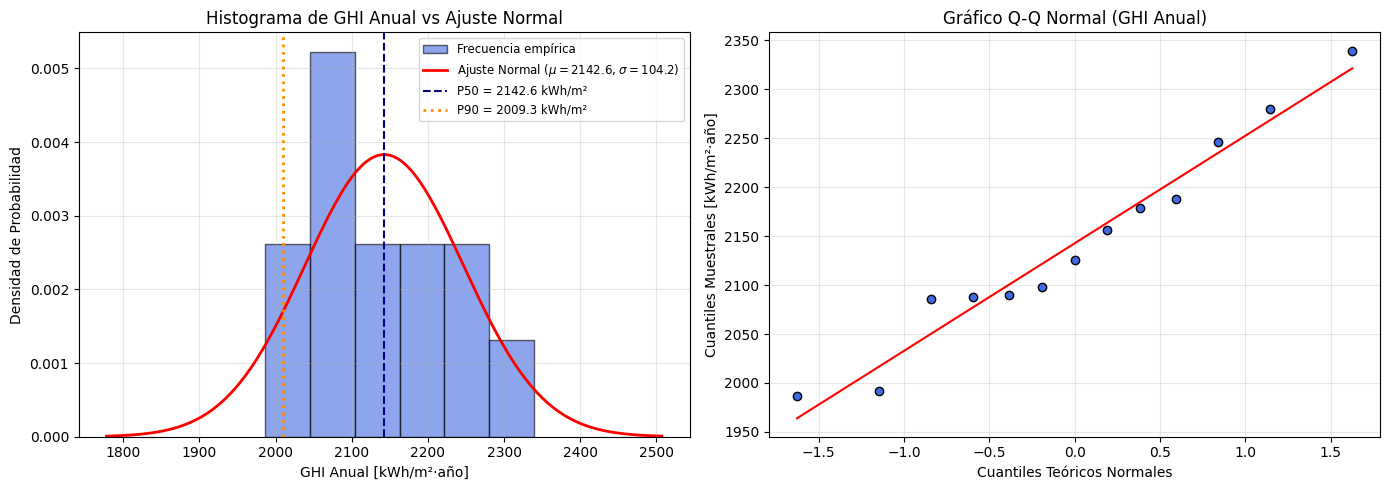

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Datos de la serie multianual
datos_ghi = anual_ghi_multi.values
mu = estad_ghi['P50 [kWh/m2 x año]']
sigma = estad_ghi['Desv. Estándar [kWh/m2 x año]']
p90 = estad_ghi['P90 [kWh/m2 x año]']

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histograma de densidades con campana normal ajustada
axs[0].hist(datos_ghi, bins=6, density=True, alpha=0.6, color='royalblue', edgecolor='black', label='Frecuencia empírica')
x_lin = np.linspace(mu - 3.5 * sigma, mu + 3.5 * sigma, 200)
axs[0].plot(x_lin, stats.norm.pdf(x_lin, mu, sigma), 'r-', lw=2, label=f'Ajuste Normal ($\mu={mu:.1f}$, $\sigma={sigma:.1f}$)')
axs[0].axvline(mu, color='navy', linestyle='--', label=f'P50 = {mu:.1f} kWh/m²')
axs[0].axvline(p90, color='darkorange', linestyle=':', lw=2, label=f'P90 = {p90:.1f} kWh/m²')
axs[0].set_title('Histograma de GHI Anual vs Ajuste Normal')
axs[0].set_xlabel('GHI Anual [kWh/m²·año]')
axs[0].set_ylabel('Densidad de Probabilidad')
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=8.5)

# 2. Gráfico Q-Q (Quantile-Quantile)
stats.probplot(datos_ghi, dist="norm", plot=axs[1])
axs[1].get_lines()[0].set_markerfacecolor('royalblue')
axs[1].get_lines()[0].set_markeredgecolor('black')
axs[1].get_lines()[1].set_color('red')
axs[1].set_title('Gráfico Q-Q Normal (GHI Anual)')
axs[1].set_xlabel('Cuantiles Teóricos Normales')
axs[1].set_ylabel('Cuantiles Muestrales [kWh/m²·año]')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## c)

Definicion de parametros iniciales

In [22]:
lat = -30.1232        
lon = -70.4926        
beta = abs(lat)       
Zs = 0.0              # 0 al apuntar hacia el ecuador
rho_g = 0.20          # albedo

Luego, se crea una fucion donde se implementa el modelo isotropico y se obtienen los angulos relevantes a partir de pvlib.

In [ ]:
def transponer_plano_inclinado(
    df,
    latitud=-30.1232,
    longitud=-70.4926,
    beta=None,
    surface_azimuth=0.0,      # Zs = 0°: Norte geográfico (orientado al ecuador en hemisferio sur)
    rho_g=0.20,               # Albedo del suelo
    tz='Etc/GMT+4'            # UTC-4 constante de Chile continental
):
    """
    Calcula todos los ángulos solares y realiza la transposición de la radiación
    al plano inclinado (I_T) mediante el modelo de cielo difuso isotrópico (Liu & Jordan)
    y la formulación geométrica de Rb (Duffie & Beckman / ICM3252).
    """
    dff = df.copy()
    
    if beta is None:
        beta = abs(latitud)
        
    # 1. Detección robusta de la columna temporal
    if 'fecha_hora' in dff.columns:
        times = pd.to_datetime(dff['fecha_hora'])
    elif 'Fecha/Hora' in dff.columns:
        times = pd.to_datetime(dff['Fecha/Hora'])
        dff['fecha_hora'] = times
    elif 'time(UTC)' in dff.columns:
        times = pd.to_datetime(dff['time(UTC)'], format='%Y%m%d:%H%M')
        dff['fecha_hora'] = times
    elif isinstance(dff.index, pd.DatetimeIndex):
        times = pd.Series(dff.index, index=dff.index)
        dff['fecha_hora'] = times.values
    else:
        date_cols = [c for c in dff.columns if any(k in c.lower() for k in ['time', 'date', 'fecha'])]
        if date_cols:
            times = pd.to_datetime(dff[date_cols[0]])
            dff['fecha_hora'] = times
        else:
            raise KeyError('No se encontró una columna temporal en el DataFrame.')

    # Localizar / convertir zona horaria para pvlib
    if times.dt.tz is None:
        times_tz = times.dt.tz_localize(tz)
    else:
        times_tz = times.dt.tz_convert(tz)
        
    times_idx = pd.DatetimeIndex(times_tz)

    # 2. Detección robusta de columnas de radiación (GHI, DNI, DHI)
    # GHI
    if 'ghi' in dff.columns:
        ghi_col = 'ghi'
    elif 'G(h)' in dff.columns:
        ghi_col = 'G(h)'
    else:
        raise KeyError("No se encontró columna para GHI ('ghi' o 'G(h)').")

    # DNI
    if 'dni' in dff.columns:
        dni_col = 'dni'
    elif 'Gb(n)' in dff.columns:
        dni_col = 'Gb(n)'
    else:
        raise KeyError("No se encontró columna para DNI ('dni' o 'Gb(n)').")

    # DHI
    if 'dhi' in dff.columns:
        dhi_col = 'dhi'
    elif 'difh' in dff.columns:
        dhi_col = 'difh'
    elif 'Gd(h)' in dff.columns:
        dhi_col = 'Gd(h)'
    else:
        raise KeyError("No se encontró columna para DHI ('dhi', 'difh' o 'Gd(h)').")

    # 3. Posición solar con pvlib (Cenit, Azimut, Elevación y Ecuación del Tiempo)
    solpos = pvlib.solarposition.get_solarposition(times_idx, latitud, longitud)
    zenith = np.asarray(solpos['zenith'])
    azimuth = np.asarray(solpos['azimuth'])
    elevation = np.asarray(solpos['elevation'])
    eot = np.asarray(solpos['equation_of_time'])

    # 4. Declinación solar (delta) y Ángulo horario (h)
    declination_rad = pvlib.solarposition.declination_spencer71(times_idx.dayofyear)
    declination_deg = np.degrees(np.asarray(declination_rad))
    h_angle = np.asarray(pvlib.solarposition.hour_angle(times_idx, longitud, eot))

    # 5. Ángulo de incidencia sobre el plano inclinado (aoi / theta)
    aoi = np.asarray(pvlib.irradiance.aoi(
        surface_tilt=beta,
        surface_azimuth=surface_azimuth,
        solar_zenith=zenith,
        solar_azimuth=azimuth
    ))

    # 6. Cosenos y Factor geométrico Rb = cos(theta) / cos(Phi)
    cos_theta = np.maximum(0.0, np.cos(np.radians(aoi)))
    cos_zenith = np.maximum(0.0, np.cos(np.radians(zenith)))

    # Cálculo seguro de Rb evitando división por cero en la noche
    es_dia = (elevation > 2.0) & (cos_zenith > 0.035)
    rb = np.divide(cos_theta, cos_zenith, out=np.zeros_like(cos_theta), where=es_dia)

    # componentes energeticas de los df
    dni = np.maximum(np.asarray(dff[dni_col]), 0.0)
    dhi = np.maximum(np.asarray(dff[dhi_col]), 0.0)
    ghi = np.maximum(np.asarray(dff[ghi_col]), 0.0)
    b_rad = np.radians(beta)

    # componente directa
    I_T_b = dni * cos_theta

    # componentye difusa
    I_T_d = dhi * ((1.0 + np.cos(b_rad)) / 2.0)

    # componente reflejada
    I_T_r = ghi * rho_g * ((1.0 - np.cos(b_rad)) / 2.0)

    # total inclinado
    I_T = I_T_b + I_T_d + I_T_r

    # asignacion al df
    dff['zenith'] = zenith
    dff['elevation'] = elevation
    dff['azimuth'] = azimuth
    dff['declination'] = declination_deg
    dff['hour_angle'] = h_angle
    dff['aoi'] = aoi
    dff['cos_zenith'] = cos_zenith
    dff['cos_theta'] = cos_theta
    dff['Rb'] = rb
    dff['I_T_b'] = I_T_b
    dff['I_T_d'] = I_T_d
    dff['I_T_r'] = I_T_r
    dff['I_T'] = I_T

    return dff


Con la funcion definida, se aplica a los 3 df, para encontrar las trasposiciones segun las dos fuentes de TMY y todos los años de la serie multianual

In [47]:
df_tmy_exp_inc = transponer_plano_inclinado(df_tmy_explorador, latitud=lat, longitud=lon, beta=beta, surface_azimuth=Zs, rho_g=rho_g)
df_tmy_pvgis_inc = transponer_plano_inclinado(df_tmy_pvgis, latitud=lat, longitud=lon, beta=beta, surface_azimuth=Zs, rho_g=rho_g)
df_multi_inc = transponer_plano_inclinado(df_multi_explorador, latitud=lat, longitud=lon, beta=beta, surface_azimuth=Zs, rho_g=rho_g)

# para los TMY de cada fuente
I_T_tmy_exp = df_tmy_exp_inc['I_T'].sum() / 1000.0     
I_T_tmy_pvgis = df_tmy_pvgis_inc['I_T'].sum() / 1000.0 

# error entre fuentes
eps_IT = ((I_T_tmy_pvgis - I_T_tmy_exp) / I_T_tmy_exp) * 100.0

#años del multianual
df_multi_inc['año'] = pd.to_datetime(df_multi_inc['fecha_hora']).dt.year
anual_IT_multi = df_multi_inc.groupby('año')['I_T'].sum() / 1000.0

I_T_P50 = anual_IT_multi.mean()
sigma_IT = anual_IT_multi.std(ddof=1)
I_T_P90 = I_T_P50 - 1.28 * sigma_IT

# sobredimensionamiento
delta_A_pct = ((I_T_P50 / I_T_P90) - 1.0) * 100.0


In [48]:
# =============================================================================
# TABLA 1: TOTALES DE IRRADIACIÓN EN PLANO INCLINADO (I_T) PARA AMBAS FUENTES TMY
# =============================================================================
df_tabla_tmy_It = pd.DataFrame({
    'Variable': ['IT Plano Inclinado [kWh/m²·año]'],
    'Explorador Solar': [round(I_T_tmy_exp, 2)],
    'PVGIS': [round(I_T_tmy_pvgis, 2)],
    'Diferencia [kWh/m²·año]': [round(I_T_tmy_pvgis - I_T_tmy_exp, 2)],
    'Desviación [%]': [round(eps_IT, 2)]
})

print("=============================================================================")
print("TABLA 1: IRRADIACIÓN ANUAL EN PLANO INCLINADO (TMY EXPLORADOR VS. PVGIS)")
print("=============================================================================")
display(df_tabla_tmy_It)

# =============================================================================
# TABLA 2: RESULTADOS DE LA SERIE MULTIANUAL Y SOBREDIMENSIONAMIENTO (ΔA%)
# =============================================================================
cv_IT = (sigma_IT / I_T_P50) * 100.0

df_tabla_multianual_It = pd.DataFrame({
    'Parámetro / Métrica': [
        'Media Multianual IT (P50)',
        'Desviación Estándar Interanual (σ)',
        'Coeficiente de Variación (CV)',
        'Escenario Conservador IT (P90)',
        'Mejor Año Histórico',
        'Peor Año Histórico',
        'Sobredimensionamiento de Área Requerido (ΔA%)'
    ],
    'Valor': [
        f"{I_T_P50:.2f} kWh/m²·año",
        f"{sigma_IT:.2f} kWh/m²·año",
        f"{cv_IT:.2f} %",
        f"{I_T_P90:.2f} kWh/m²·año",
        f"{anual_IT_multi.max():.2f} kWh/m²·año ({anual_IT_multi.idxmax()})",
        f"{anual_IT_multi.min():.2f} kWh/m²·año ({anual_IT_multi.idxmin()})",
        f"{delta_A_pct:.2f} %"
    ]
})

print("\n=============================================================================")
print("TABLA 2: SERIE MULTIANUAL Y SOBREDIMENSIONAMIENTO P50 VS. P90")
print("=============================================================================")
display(df_tabla_multianual_It)


TABLA 1: IRRADIACIÓN ANUAL EN PLANO INCLINADO (TMY EXPLORADOR VS. PVGIS)


,Variable,Explorador Solar,PVGIS,Diferencia [kWh/m²·año],Desviación [%]
0,IT Plano Inclinado [kWh/m²·año],2205.84,1901.26,-304.59,-13.81



TABLA 2: SERIE MULTIANUAL Y SOBREDIMENSIONAMIENTO P50 VS. P90


,Parámetro / Métrica,Valor
0,Media Multianual IT (P50),2232.78 kWh/m²·año
1,Desviación Estándar Interanual (σ),163.10 kWh/m²·año
2,Coeficiente de Variación (CV),7.30 %
3,Escenario Conservador IT (P90),2024.01 kWh/m²·año
4,Mejor Año Histórico,2543.27 kWh/m²·año (2010)
5,Peor Año Histórico,2017.33 kWh/m²·año (2016)
6,Sobredimensionamiento de Área Requerido (ΔA%),10.31 %
